In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from utils import (
    plot_conjuntos_fuzzy,
    salvar_figura_conjunto_saida,
    salvar_figura_implicacoes,
    gerar_conjuntos_fuzzy_por_amostra,
    gerar_conjuntos_fuzzy_velocidade_vento,
    gerar_conjuntos_fuzzy_umidade_relativa,
    gerar_conjuntos_fuzzy_vibracao_torre,
    gerar_conjuntos_fuzzy_risco_fadiga,
    TNORMAS_DISPONIVEIS,
    TCONORMAS_DISPONIVEIS,
    DEFUZZICADORES_DISPONIVEIS,
    DEFAULT_TNORMA,
    DEFAULT_TCONORNA,
    DEFAULT_DEFUZZIFICADOR,
    UNIVERSOS_DISCURSO,
)

DATA_DIR = Path("../data")

OPERADOR_FUZZY = "hamacher"
DEFUZZIFICADOR = "centro_gravidade"
AMOSTRA_SAIDA_VISUALIZAR = 0
FIGURA_DPI = 600

OUTPUT_DIR = Path("../output") / OPERADOR_FUZZY
FIGURAS_DIR = OUTPUT_DIR / "figuras"
FIGURAS_CONJUNTOS_DIR = FIGURAS_DIR / "conjuntos"
FIGURAS_IMPLICACOES_DIR = FIGURAS_DIR / "implicacoes"
FIGURAS_SAIDA_DIR = FIGURAS_DIR / "saida"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURAS_CONJUNTOS_DIR.mkdir(parents=True, exist_ok=True)
FIGURAS_IMPLICACOES_DIR.mkdir(parents=True, exist_ok=True)
FIGURAS_SAIDA_DIR.mkdir(parents=True, exist_ok=True)


## Carregar dados e montar universos de discursos

In [2]:
coletas_df = pd.read_csv(DATA_DIR / "coletas.csv")
coletas_df.head()


,coleta,velocidade_vento,umidade_relativa,vibracao_torre
0,1,5.2,18,0.8
1,2,7.5,35,1.9
2,3,10.8,42,3.2
3,4,13.6,58,4.5
4,5,15.4,67,5.1


In [3]:
universos_discurso = UNIVERSOS_DISCURSO

print("Universos de discurso:")
for var, universo in universos_discurso.items():
    print(f"{var}: {universo[0]} a {universo[-1]} (passo {universo[1] - universo[0]})")

Universos de discurso:
velocidade_vento: 0.0 a 35.0 (passo 0.1)
umidade_relativa: 0 a 100 (passo 1)
vibracao_torre: 0.0 a 10.0 (passo 0.1)
risco_fadiga: 0 a 100 (passo 1)


## Conjuntos Fuzzy

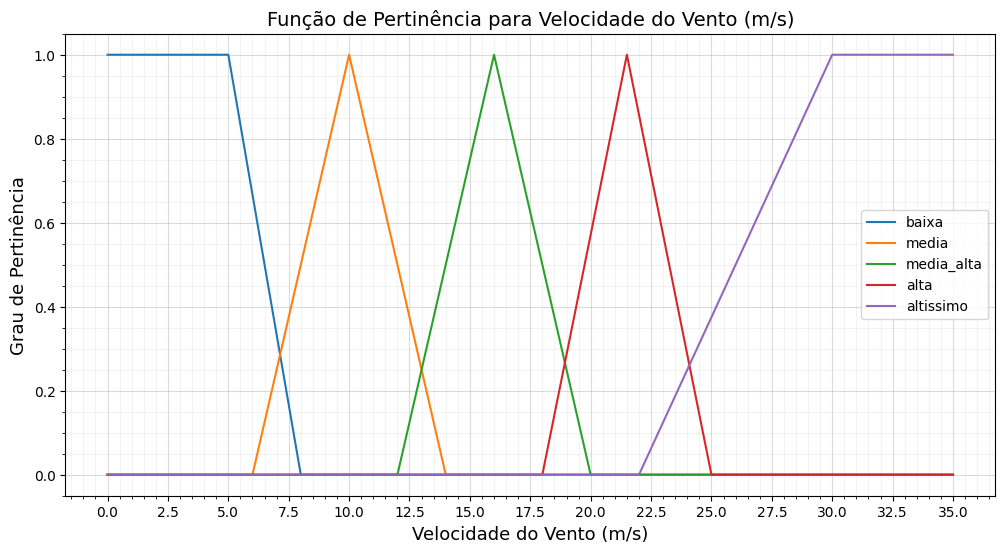

In [4]:
conjuntos_velocidade_vento = gerar_conjuntos_fuzzy_velocidade_vento(
    universos_discurso['velocidade_vento']
)

plot_conjuntos_fuzzy(
    universos_discurso['velocidade_vento'],
    'Velocidade do Vento (m/s)',
    conjuntos_velocidade_vento,
    xlabel='Velocidade do Vento (m/s)',
    xtick_step=2.5,
    caminho_saida=FIGURAS_CONJUNTOS_DIR / 'conjuntos_fuzzy_velocidade_vento.png',
    dpi=FIGURA_DPI,
)


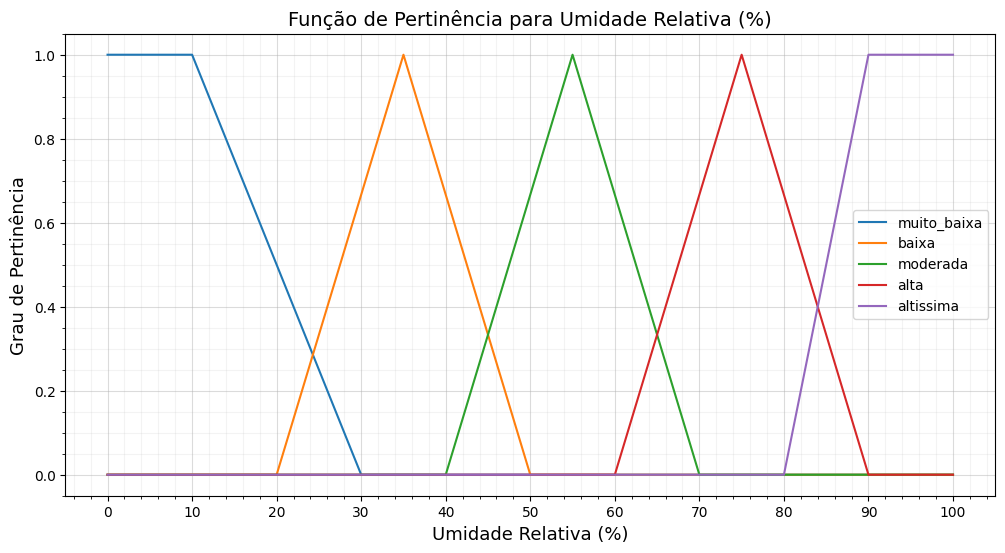

In [5]:
conjuntos_umidade_relativa = gerar_conjuntos_fuzzy_umidade_relativa(
    universos_discurso['umidade_relativa']
)

plot_conjuntos_fuzzy(
    universos_discurso['umidade_relativa'],
    'Umidade Relativa (%)',
    conjuntos_umidade_relativa,
    xlabel='Umidade Relativa (%)',
    xtick_step=10,
    caminho_saida=FIGURAS_CONJUNTOS_DIR / 'conjuntos_fuzzy_umidade_relativa.png',
    dpi=FIGURA_DPI,
)


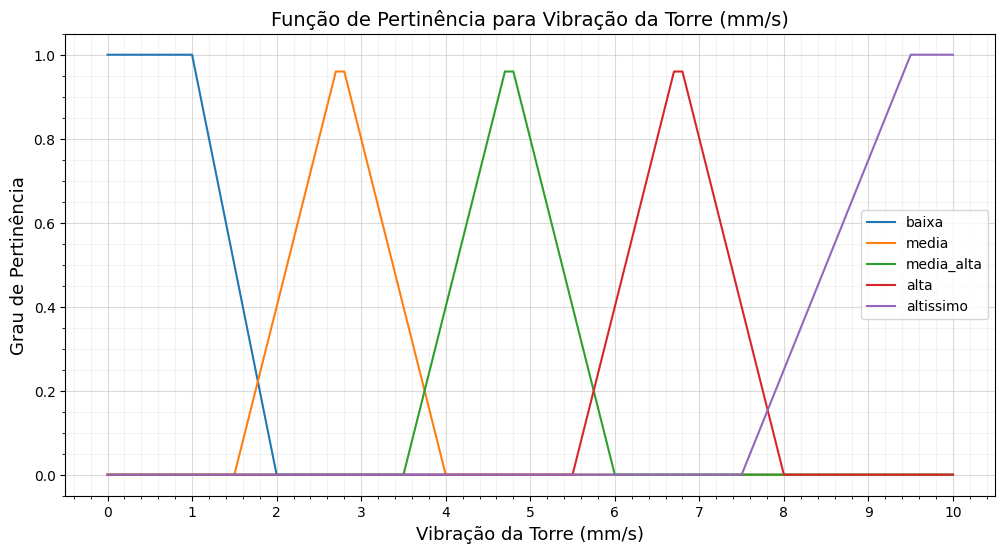

In [6]:
conjuntos_vibracao_torre = gerar_conjuntos_fuzzy_vibracao_torre(
    universos_discurso['vibracao_torre']
)

plot_conjuntos_fuzzy(
    universos_discurso['vibracao_torre'],
    'Vibração da Torre (mm/s)',
    conjuntos_vibracao_torre,
    xlabel='Vibração da Torre (mm/s)',
    xtick_step=1,
    caminho_saida=FIGURAS_CONJUNTOS_DIR / 'conjuntos_fuzzy_vibracao_torre.png',
    dpi=FIGURA_DPI,
)


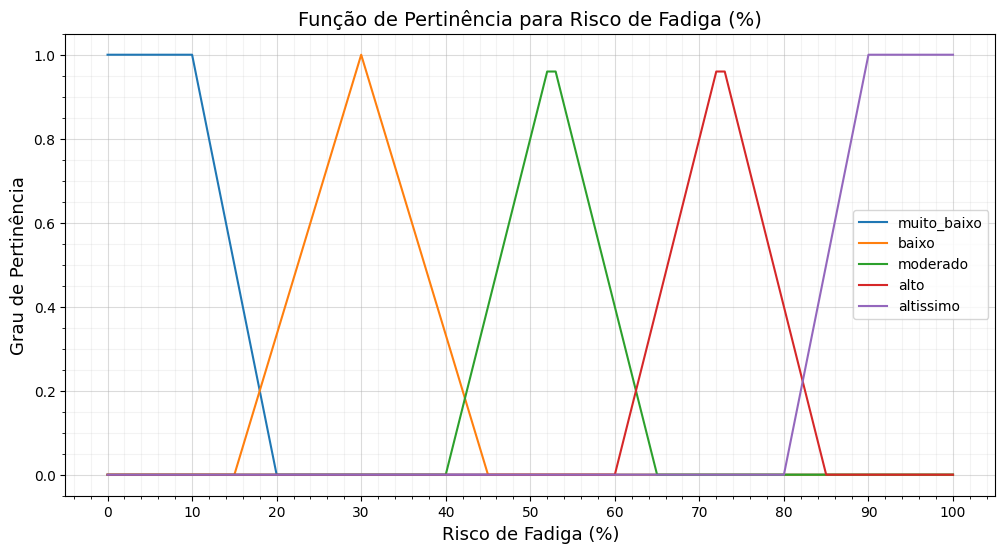

In [7]:
conjuntos_risco_fadiga = gerar_conjuntos_fuzzy_risco_fadiga(
    universos_discurso['risco_fadiga']
)

plot_conjuntos_fuzzy(
    universos_discurso['risco_fadiga'],
    'Risco de Fadiga (%)',
    conjuntos_risco_fadiga,
    xlabel='Risco de Fadiga (%)',
    xtick_step=10,
    caminho_saida=FIGURAS_CONJUNTOS_DIR / 'conjuntos_fuzzy_risco_fadiga.png',
    dpi=FIGURA_DPI,
)


## Fuzzyficação

In [8]:
pertinencias_por_amostra = {
    amostra_idx: gerar_conjuntos_fuzzy_por_amostra(amostra)
    for amostra_idx, amostra in coletas_df.iterrows()
}

linhas_fuzzyficacao = []

for amostra_idx, pertinencias_amostra in pertinencias_por_amostra.items():
    amostra = coletas_df.loc[amostra_idx]

    for conjunto_velocidade, mu_velocidade in pertinencias_amostra['velocidade_vento'].items():
        for conjunto_umidade, mu_umidade in pertinencias_amostra['umidade_relativa'].items():
            for conjunto_vibracao, mu_vibracao in pertinencias_amostra['vibracao_torre'].items():
                linhas_fuzzyficacao.append({
                    'amostra': amostra_idx,
                    'valor_velocidade_vento': amostra['velocidade_vento'],
                    'conjunto_velocidade_vento': conjunto_velocidade,
                    'pertinencia_velocidade_vento': mu_velocidade,
                    'valor_umidade_relativa': amostra['umidade_relativa'],
                    'conjunto_umidade_relativa': conjunto_umidade,
                    'pertinencia_umidade_relativa': mu_umidade,
                    'valor_vibracao_torre': amostra['vibracao_torre'],
                    'conjunto_vibracao_torre': conjunto_vibracao,
                    'pertinencia_vibracao_torre': mu_vibracao,
                })

fuzzyficacao_df = pd.DataFrame(linhas_fuzzyficacao)

colunas_pertinencia_antecedentes = [
    'pertinencia_velocidade_vento',
    'pertinencia_umidade_relativa',
    'pertinencia_vibracao_torre',
]

fuzzyficacao_ativa_df = fuzzyficacao_df[
    fuzzyficacao_df[colunas_pertinencia_antecedentes].gt(0).all(axis=1)
].reset_index(drop=True)

fuzzyficacao_df.to_csv(OUTPUT_DIR / "fuzzyficacao_completa.csv", index=False)
fuzzyficacao_ativa_df.to_csv(OUTPUT_DIR / "fuzzyficacao_ativa.csv", index=False)

fuzzyficacao_ativa_df.head(10)


,amostra,valor_velocidade_vento,conjunto_velocidade_vento,pertinencia_velocidade_vento,valor_umidade_relativa,conjunto_umidade_relativa,pertinencia_umidade_relativa,valor_vibracao_torre,conjunto_vibracao_torre,pertinencia_vibracao_torre
0,0,5.2,baixa,0.933333,18.0,muito_baixa,0.600000,0.8,baixa,1.00
1,1,7.5,baixa,0.166667,35.0,baixa,1.000000,1.9,baixa,0.10
2,1,7.5,baixa,0.166667,35.0,baixa,1.000000,1.9,media,0.32
3,1,7.5,media,0.375000,35.0,baixa,1.000000,1.9,baixa,0.10
4,1,7.5,media,0.375000,35.0,baixa,1.000000,1.9,media,0.32
5,2,10.8,media,0.800000,42.0,baixa,0.533333,3.2,media,0.64
6,2,10.8,media,0.800000,42.0,moderada,0.133333,3.2,media,0.64
7,3,13.6,media,0.100000,58.0,moderada,0.800000,4.5,media_alta,0.80
8,3,13.6,media_alta,0.400000,58.0,moderada,0.800000,4.5,media_alta,0.80
9,4,15.4,media_alta,0.850000,67.0,moderada,0.200000,5.1,media_alta,0.72


## Base de regras

In [9]:
with open(DATA_DIR / "regras.json", encoding="utf-8") as arquivo_regras:
    base_regras = json.load(arquivo_regras)

regras_por_antecedente = {
    (
        regra['velocidade_vento'],
        regra['umidade_relativa'],
        regra['vibracao_torre'],
    ): regra
    for regra in base_regras
}

regras_df = pd.DataFrame(base_regras)
regras_df.to_csv(OUTPUT_DIR / "regras.csv", index=False)
regras_df.head()


,regra,velocidade_vento,umidade_relativa,vibracao_torre,risco_fadiga,sigla_risco_fadiga
0,R1,baixa,muito_baixa,baixa,muito_baixo,MB
1,R2,baixa,baixa,baixa,muito_baixo,MB
2,R3,baixa,moderada,baixa,baixo,B
3,R4,baixa,alta,baixa,baixo,B
4,R5,baixa,altissima,baixa,moderado,MO


## Sistema de Inferência (Mamdani)

### Operadores fuzzy


In [10]:
tnorma_inferencia = TNORMAS_DISPONIVEIS.get(OPERADOR_FUZZY, DEFAULT_TNORMA)
tconorma_agregacao = TCONORMAS_DISPONIVEIS.get(OPERADOR_FUZZY, DEFAULT_TCONORNA)

OPERADOR_FUZZY


'hamacher'

### Regras ativadas


In [11]:
regras_ativadas_df = fuzzyficacao_ativa_df.merge(
    regras_df,
    left_on=[
        'conjunto_velocidade_vento',
        'conjunto_umidade_relativa',
        'conjunto_vibracao_torre',
    ],
    right_on=[
        'velocidade_vento',
        'umidade_relativa',
        'vibracao_torre',
    ],
    how='inner',
)

regras_ativadas_df['forca_ativacao'] = regras_ativadas_df.apply(
    lambda linha: tnorma_inferencia(
        tnorma_inferencia(
            linha['pertinencia_velocidade_vento'],
            linha['pertinencia_umidade_relativa'],
        ),
        linha['pertinencia_vibracao_torre'],
    ),
    axis=1,
)

regras_ativadas_df['proposicao'] = regras_ativadas_df.apply(
    lambda linha: (
        f"SE velocidade_vento É {linha['conjunto_velocidade_vento']} "
        f"E umidade_relativa É {linha['conjunto_umidade_relativa']} "
        f"E vibracao_torre É {linha['conjunto_vibracao_torre']} "
        f"ENTÃO risco_fadiga É {linha['risco_fadiga']}"
    ),
    axis=1,
)

colunas_inferencia_regras = [
    'amostra',
    'regra',
    'proposicao',
    'valor_velocidade_vento',
    'conjunto_velocidade_vento',
    'pertinencia_velocidade_vento',
    'valor_umidade_relativa',
    'conjunto_umidade_relativa',
    'pertinencia_umidade_relativa',
    'valor_vibracao_torre',
    'conjunto_vibracao_torre',
    'pertinencia_vibracao_torre',
    'forca_ativacao',
    'risco_fadiga',
    'sigla_risco_fadiga',
]

inferencia_regras_df = regras_ativadas_df[colunas_inferencia_regras].sort_values(
    ['amostra', 'regra']
).reset_index(drop=True)

inferencia_regras_df.head(10)


,amostra,regra,proposicao,valor_velocidade_vento,conjunto_velocidade_vento,pertinencia_velocidade_vento,valor_umidade_relativa,conjunto_umidade_relativa,pertinencia_umidade_relativa,valor_vibracao_torre,conjunto_vibracao_torre,pertinencia_vibracao_torre,forca_ativacao,risco_fadiga,sigla_risco_fadiga
0,0,R1,SE velocidade_vento É baixa E umidade_relativa...,5.2,baixa,0.933333,18.0,muito_baixa,0.600000,0.8,baixa,1.00,0.575342,muito_baixo,MB
1,1,R2,SE velocidade_vento É baixa E umidade_relativa...,7.5,baixa,0.166667,35.0,baixa,1.000000,1.9,baixa,0.10,0.066667,muito_baixo,MB
2,1,R7,SE velocidade_vento É media E umidade_relativa...,7.5,media,0.375000,35.0,baixa,1.000000,1.9,baixa,0.10,0.085714,baixo,B
3,2,R8,SE velocidade_vento É media E umidade_relativa...,10.8,media,0.800000,42.0,moderada,0.133333,3.2,media,0.64,0.120301,moderado,MO
4,3,R13,SE velocidade_vento É media_alta E umidade_rel...,13.6,media_alta,0.400000,58.0,moderada,0.800000,4.5,media_alta,0.80,0.333333,alto,A
5,4,R13,SE velocidade_vento É media_alta E umidade_rel...,15.4,media_alta,0.850000,67.0,moderada,0.200000,5.1,media_alta,0.72,0.179683,alto,A
6,4,R14,SE velocidade_vento É media_alta E umidade_rel...,15.4,media_alta,0.850000,67.0,alta,0.466667,5.1,media_alta,0.72,0.369247,alto,A
7,5,R19,SE velocidade_vento É alta E umidade_relativa ...,18.9,alta,0.257143,74.0,alta,0.933333,6.4,alta,0.72,0.229927,altissimo,AL
8,6,R19,SE velocidade_vento É alta E umidade_relativa ...,21.7,alta,0.942857,83.0,alta,0.466667,7.2,alta,0.64,0.361538,altissimo,AL
9,6,R20,SE velocidade_vento É alta E umidade_relativa ...,21.7,alta,0.942857,83.0,altissima,0.300000,7.2,alta,0.64,0.252753,altissimo,AL


### Implicação


In [12]:
linhas_implicacao = []
universo_risco_fadiga = universos_discurso['risco_fadiga']

for _, regra_ativada in inferencia_regras_df.iterrows():
    conjunto_risco = conjuntos_risco_fadiga[regra_ativada['risco_fadiga']]

    for valor_risco, pertinencia_risco in zip(universo_risco_fadiga, conjunto_risco):
        linhas_implicacao.append({
            'amostra': regra_ativada['amostra'],
            'regra': regra_ativada['regra'],
            'risco_fadiga': regra_ativada['risco_fadiga'],
            'valor_risco_fadiga': valor_risco,
            'pertinencia_risco_fadiga': pertinencia_risco,
            'forca_ativacao': regra_ativada['forca_ativacao'],
            'pertinencia_implicacao': tnorma_inferencia(
                regra_ativada['forca_ativacao'],
                pertinencia_risco,
            ),
        })

inferencia_implicacoes_df = pd.DataFrame(linhas_implicacao)
inferencia_implicacoes_df.head(10)


,amostra,regra,risco_fadiga,valor_risco_fadiga,pertinencia_risco_fadiga,forca_ativacao,pertinencia_implicacao
0,0,R1,muito_baixo,0,1.0,0.575342,0.575342
1,0,R1,muito_baixo,1,1.0,0.575342,0.575342
2,0,R1,muito_baixo,2,1.0,0.575342,0.575342
3,0,R1,muito_baixo,3,1.0,0.575342,0.575342
4,0,R1,muito_baixo,4,1.0,0.575342,0.575342
5,0,R1,muito_baixo,5,1.0,0.575342,0.575342
6,0,R1,muito_baixo,6,1.0,0.575342,0.575342
7,0,R1,muito_baixo,7,1.0,0.575342,0.575342
8,0,R1,muito_baixo,8,1.0,0.575342,0.575342
9,0,R1,muito_baixo,9,1.0,0.575342,0.575342


### Figuras das implicações


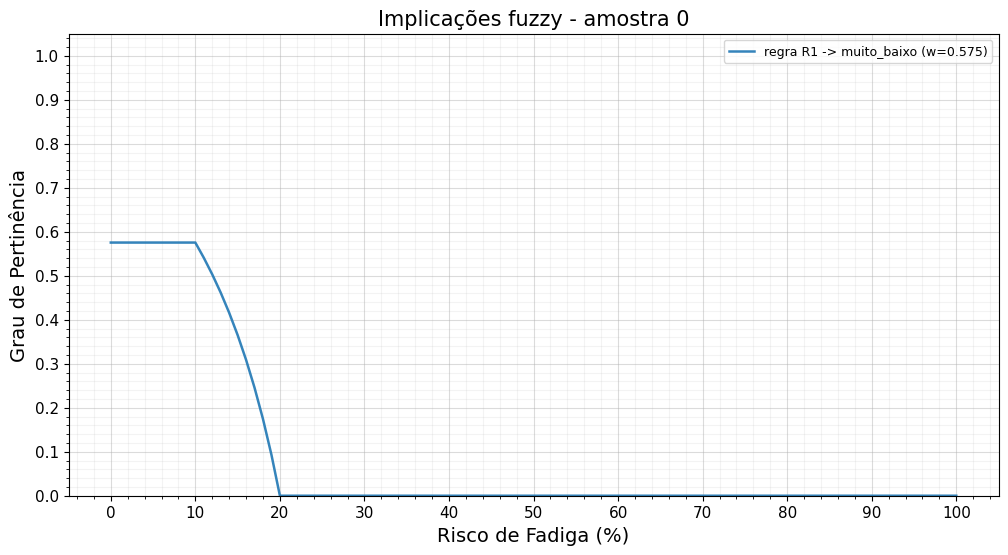

PosixPath('../output/hamacher/figuras/implicacoes/implicacoes_amostra_0.png')

In [13]:
figuras_implicacoes = [
    salvar_figura_implicacoes(
        inferencia_implicacoes_df,
        FIGURAS_IMPLICACOES_DIR,
        amostra_idx,
        dpi=FIGURA_DPI,
    )
    for amostra_idx in sorted(inferencia_implicacoes_df['amostra'].unique())
]

figura_implicacao_visualizada = salvar_figura_implicacoes(
    inferencia_implicacoes_df,
    FIGURAS_IMPLICACOES_DIR,
    AMOSTRA_SAIDA_VISUALIZAR,
    exibir=True,
    dpi=FIGURA_DPI,
)

figura_implicacao_visualizada


### Agregação


In [14]:
linhas_agregacao = []

for (amostra_idx, valor_risco), implicacoes in inferencia_implicacoes_df.groupby(
    ['amostra', 'valor_risco_fadiga'],
    sort=True,
):
    pertinencia_agregada = 0.0
    for pertinencia_implicacao in implicacoes['pertinencia_implicacao']:
        pertinencia_agregada = tconorma_agregacao(
            pertinencia_agregada,
            pertinencia_implicacao,
        )

    linhas_agregacao.append({
        'amostra': amostra_idx,
        'valor_risco_fadiga': valor_risco,
        'pertinencia_agregada': pertinencia_agregada,
    })

agregacao_df = pd.DataFrame(linhas_agregacao)
agregacao_df.head(10)


,amostra,valor_risco_fadiga,pertinencia_agregada
0,0,0,0.575342
1,0,1,0.575342
2,0,2,0.575342
3,0,3,0.575342
4,0,4,0.575342
5,0,5,0.575342
6,0,6,0.575342
7,0,7,0.575342
8,0,8,0.575342
9,0,9,0.575342


### Exportar inferência


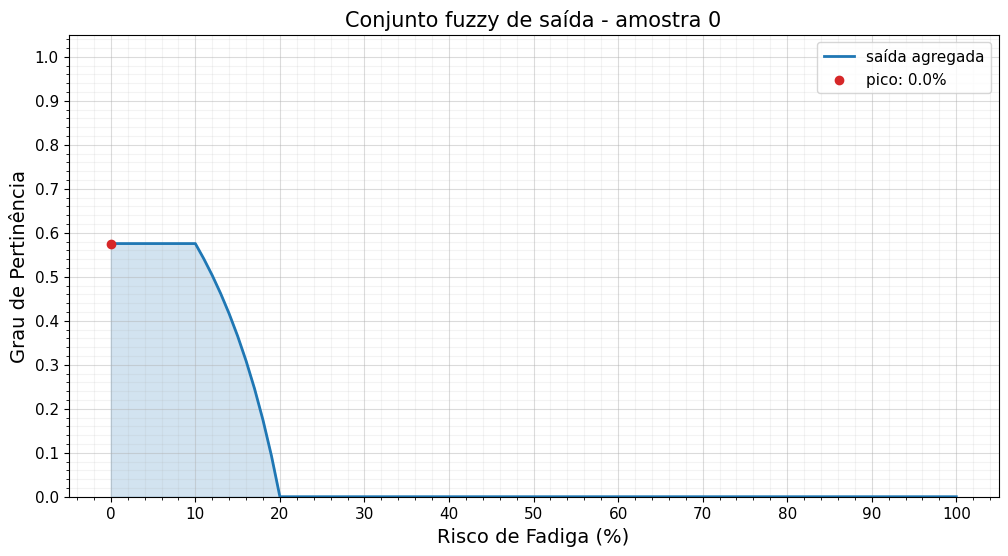

PosixPath('../output/hamacher/figuras/saida/conjunto_saida_amostra_0.png')

In [15]:
figuras_saida = [
    salvar_figura_conjunto_saida(
        agregacao_df,
        FIGURAS_SAIDA_DIR,
        amostra_idx,
        dpi=FIGURA_DPI,
    )
    for amostra_idx in sorted(agregacao_df['amostra'].unique())
]

figura_amostra_visualizada = salvar_figura_conjunto_saida(
    agregacao_df,
    FIGURAS_SAIDA_DIR,
    AMOSTRA_SAIDA_VISUALIZAR,
    exibir=True,
    dpi=FIGURA_DPI,
)

figura_amostra_visualizada

In [16]:
inferencia_regras_df.to_csv(OUTPUT_DIR / "inferencia_regras.csv", index=False)
inferencia_implicacoes_df.to_csv(OUTPUT_DIR / "inferencia_implicacoes.csv", index=False)
agregacao_df.to_csv(OUTPUT_DIR / "agregacao.csv", index=False)

[
    OUTPUT_DIR / "inferencia_regras.csv",
    OUTPUT_DIR / "inferencia_implicacoes.csv",
    OUTPUT_DIR / "agregacao.csv",
]


[PosixPath('../output/hamacher/inferencia_regras.csv'),
 PosixPath('../output/hamacher/inferencia_implicacoes.csv'),
 PosixPath('../output/hamacher/agregacao.csv')]

## Defuzzyficação

In [17]:
defuzzificador = DEFUZZICADORES_DISPONIVEIS.get(DEFUZZIFICADOR, DEFAULT_DEFUZZIFICADOR)

ROTULOS_RISCO_FADIGA = {
    'muito_baixo': 'Muito baixo',
    'baixo': 'Baixo',
    'moderado': 'Moderado',
    'alto': 'Alto',
    'altissimo': 'Altíssimo',
}

DECISOES_OPERACIONAIS = {
    'Muito baixo': 'Manter turbinas',
    'Baixo': 'Manter turbinas',
    'Moderado': 'Manter turbinas',
    'Alto': 'Parar turbinas',
    'Altíssimo': 'Parar turbinas',
}


def categorizar_risco_fadiga(valor_defuzzificado: float) -> str:
    pertinencias_rotulos = {
        nome_conjunto: np.interp(
            valor_defuzzificado,
            universos_discurso['risco_fadiga'],
            pertinencias,
        )
        for nome_conjunto, pertinencias in conjuntos_risco_fadiga.items()
    }
    nome_conjunto_maior_pertinencia = max(
        pertinencias_rotulos,
        key=pertinencias_rotulos.get,
    )
    return ROTULOS_RISCO_FADIGA[nome_conjunto_maior_pertinencia]


def decidir_operacao_turbinas(categoria_risco_fadiga: str) -> str:
    return DECISOES_OPERACIONAIS[categoria_risco_fadiga]


resumo_regras_ativadas_df = inferencia_regras_df.groupby('amostra').agg(
    regras_ativadas=('regra', lambda regras: ', '.join(regras.astype(str))),
    qtd_regras_ativadas=('regra', 'count'),
    proposicoes_ativadas=('proposicao', lambda proposicoes: ' | '.join(proposicoes)),
).reset_index()

amostras_idx = agregacao_df['amostra'].unique()

saida_fuzzificacao_amostras = []

for amostra_idx in amostras_idx:
    agregacao_amostra = agregacao_df[agregacao_df['amostra'] == amostra_idx]

    valor_defuzzificado = defuzzificador(
        agregacao_amostra['valor_risco_fadiga'].values,
        agregacao_amostra['pertinencia_agregada'].values,
    )
    categoria_risco_fadiga = categorizar_risco_fadiga(valor_defuzzificado)

    saida_fuzzificacao_amostras.append({
        'amostra': amostra_idx,
        'velocidade_vento': coletas_df.loc[amostra_idx, 'velocidade_vento'],
        'umidade_relativa': coletas_df.loc[amostra_idx, 'umidade_relativa'],
        'vibracao_torre': coletas_df.loc[amostra_idx, 'vibracao_torre'],
        'valor_risco_fadiga': valor_defuzzificado,
        'categoria_risco_fadiga': categoria_risco_fadiga,
        'decisao_operacional': decidir_operacao_turbinas(categoria_risco_fadiga),
    })

saida_fuzzificacao_df = pd.DataFrame(saida_fuzzificacao_amostras).merge(
    resumo_regras_ativadas_df,
    on='amostra',
    how='left',
)
saida_fuzzificacao_df.to_csv(OUTPUT_DIR / "saida_fuzzificacao.csv", index=False)
saida_fuzzificacao_df.head(len(saida_fuzzificacao_df))


,amostra,velocidade_vento,umidade_relativa,vibracao_torre,valor_risco_fadiga,categoria_risco_fadiga,decisao_operacional,regras_ativadas,qtd_regras_ativadas,proposicoes_ativadas
0,0,5.2,18,0.8,7.942301,Muito baixo,Manter turbinas,R1,1,SE velocidade_vento É baixa E umidade_relativa...
1,1,7.5,35,1.9,22.283110,Baixo,Manter turbinas,"R2, R7",2,SE velocidade_vento É baixa E umidade_relativa...
2,2,10.8,42,3.2,52.500000,Moderado,Manter turbinas,R8,1,SE velocidade_vento É media E umidade_relativa...
3,3,13.6,58,4.5,72.500000,Alto,Parar turbinas,R13,1,SE velocidade_vento É media_alta E umidade_rel...
4,4,15.4,67,5.1,72.500000,Alto,Parar turbinas,"R13, R14",2,SE velocidade_vento É media_alta E umidade_rel...
5,5,18.9,74,6.4,91.450654,Altíssimo,Parar turbinas,R19,1,SE velocidade_vento É alta E umidade_relativa ...
6,6,21.7,83,7.2,91.486993,Altíssimo,Parar turbinas,"R19, R20",2,SE velocidade_vento É alta E umidade_relativa ...
7,7,24.5,91,8.3,91.406691,Altíssimo,Parar turbinas,R25,1,SE velocidade_vento É altissimo E umidade_rela...
8,8,27.8,96,9.1,92.105722,Altíssimo,Parar turbinas,R25,1,SE velocidade_vento É altissimo E umidade_rela...
9,9,12.4,49,3.8,59.228072,Moderado,Manter turbinas,"R12, R13, R8",3,SE velocidade_vento É media_alta E umidade_rel...
